# Exploratory notebook — CIFAR-10 adversarial ML project

This notebook is for quick inspection. Prefer `python run_project.py` for the full evaluation.

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import torch

from models import build_model, get_device
from utils.data import CLASS_NAMES, denormalize, get_dataloaders

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


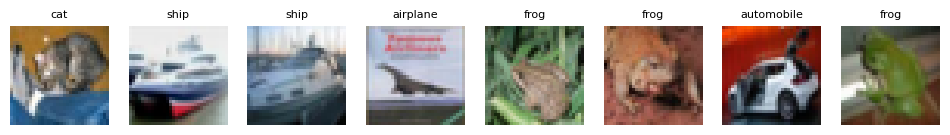

params: 1181386
device: mps


In [2]:
device = get_device()
train_loader, test_loader = get_dataloaders(data_dir=ROOT / 'data', batch_size=64, subset_size=512)
images, labels = next(iter(test_loader))
vis = denormalize(images[:8])

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(vis[i].permute(1, 2, 0).numpy())
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=8)
    ax.axis('off')
plt.show()

model = build_model().to(device)
print('params:', sum(p.numel() for p in model.parameters()))
print('device:', device)